## **Dataset Loading  and Understanding**

In [2]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the product behavior dataset.
# low_memory=False helps Pandas infer data types more consistently on large CSV files.

file_path = "../data/2019-Oct.csv"

df = pd.read_csv(
    file_path,
    low_memory=False
)

In [4]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.62,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.96,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.16,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.71,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.01,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


In [5]:
# Check dataset size: number of rows and columns.
df.shape

(42448764, 9)

**Inspect column names, data types, and missing values.**

In [6]:
# Inspect column names, data types.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 2.8 GB


In [7]:
# Convert the "event_time" column to datetime format for easier time-based analysis.
df["event_time"] = pd.to_datetime(df["event_time"])

In [8]:
df["event_time"].dtype

datetime64[us, UTC]

In [9]:
# Count missing values per column.
df.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

In [10]:
# Preview event types such as view, cart, purchase.
event_summary = df["event_type"].value_counts().reset_index()

In [11]:
# display events types and their counts
event_summary

,event_type,count
0,view,40779399
1,cart,926516
2,purchase,742849


`event_type` describes the type of user interaction recorded in each row.

In this dataset, the main event types are:

| event_type | Meaning |
|---|---|
| `view` | The user viewed a product |
| `cart` | The user added a product to the cart |
| `purchase` | The user completed a purchase |

These events can be interpreted as stages in a possible customer journey:

view → cart → purchase

However, this does not mean every user follows this exact order. Some users may only view products, some may add products to cart without purchasing, and some purchases may appear without a previous cart event inside the available dataset period.

---
### **Product Behavior Analysis**

In [12]:
# Count each user action type.
event_summary

,event_type,count
0,view,40779399
1,cart,926516
2,purchase,742849


**Event Distribution Visualization**

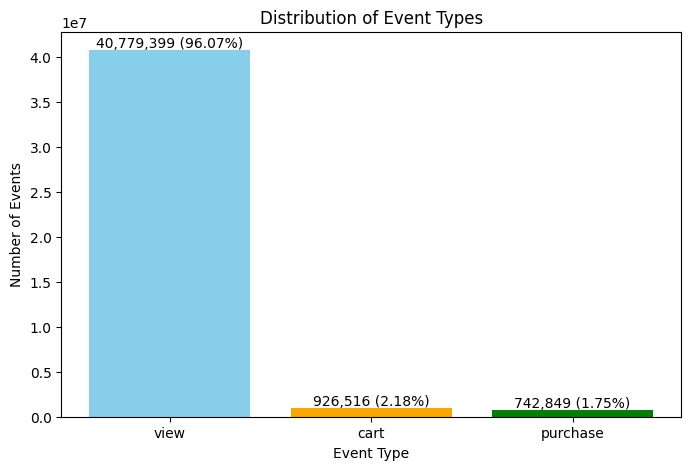

In [13]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    event_summary["event_type"],
    event_summary["count"],
    color=["skyblue", "orange", "green"]
)


plt.title("Distribution of Event Types")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f} ({height/(event_summary['count'].sum()):.2%})",
        ha="center",
        va="bottom"
    )

plt.show()

**Dominant Event Type**

The `view` event overwhelmingly dominates the dataset, accounting for approximately `96%` of all recorded events. This indicates that most user interactions involve browsing products rather than taking actions closer to a purchase.

**Purchase Frequency**

Purchasing is relatively rare. `purchase` events represent only about `1.75%` of all recorded events, making them one of the least frequent user actions in the dataset.

**Expected E-Commerce Behavior**

This pattern is expected in e-commerce because customers typically browse many products before making a purchase decision. Most visitors explore product pages, compare alternatives, and leave the website without completing a transaction. As a result, `view` events naturally occur much more frequently than `purchase` events.

 **Gap Between Views and Purchases**

A large gap between `view` and `purchase` events suggests a significant drop-off throughout the customer journey. While many users show interest in products by viewing them, only a small proportion proceed to purchase. This may indicate friction in the buying process, price sensitivity, lack of purchase intent, or opportunities to improve the overall shopping experience.

 **Business Opportunities**

The large volume of product views creates several opportunities for the business:

- Improve `conversion rates` by optimizing product pages and checkout processes.
- Identify products that receive substantial attention but generate relatively few purchases.
- Implement `retargeting campaigns` for users who viewed products but did not convert.
- Use `personalized recommendations` to encourage further engagement and purchases.
- Analyze `customer behavior` to better understand where users abandon the purchasing journey.

Given the extremely high number of product views, even a modest improvement in the `conversion rate (Purchases/Views)` could result in a meaningful increase in sales and revenue.

**Funnel Metrics and Conversion Rates**

In [14]:
views = (df["event_type"] == "view").sum()
carts = (df["event_type"] == "cart").sum()
purchases = (df["event_type"] == "purchase").sum()
funnel_df = pd.DataFrame({
    "Stage": [
        "View",
        "Cart",
        "Purchase"
    ],
    "Users": [
        views,
        carts,
        purchases
    ]
})
funnel_df

,Stage,Users
0,View,40779399
1,Cart,926516
2,Purchase,742849


In [15]:
view_to_cart = carts / views * 100
cart_to_purchase = purchases / carts * 100
view_to_purchase = purchases / views * 100

conversion_summary = pd.DataFrame({
    "Metric": [
        "View → Cart",
        "Cart → Purchase",
        "View → Purchase"
    ],
    "Conversion Rate (%)": [
        round(view_to_cart, 2),
        round(cart_to_purchase, 2),
        round(view_to_purchase, 2)
    ]
})

conversion_summary

,Metric,Conversion Rate (%)
0,View → Cart,2.27
1,Cart → Purchase,80.18
2,View → Purchase,1.82


**Biggest Funnel Drop-Off**

The largest drop-off occurs between `view` and `cart` events. Many users browse products, but only a small percentage add items to their cart.

**Potential Reasons for Abandonment**

Possible reasons include high prices, lack of purchase intent, insufficient product information, or concerns about shipping and delivery.

**Product Improvement Opportunities**

- Improve `product descriptions` and images.
- Increase visibility of `reviews` and ratings.
- Offer promotions and personalized recommendations.
- Simplify the shopping experience.

**Key Weekly Executive Metric**

The most important metric is the `view-to-cart conversion rate`, as it measures how effectively product views turn into buying intent.

**Value of Funnel Analysis**

`Funnel analysis` identifies where customers drop off in the purchasing journey, helping the business target improvements more effectively than revenue metrics alone.

---

## **User Analytics**

**User Engagement KPIs**

In [16]:
# Count unique users in the platform.

unique_users = df["user_id"].nunique()
unique_sessions = df["user_session"].nunique()
summary_df = pd.DataFrame({
    "KPI": [
        "Total Events",
        "Unique Users",
        "Average Events per User",
        "Average Events per Session",
        "Average Sessions per User"
    ],
    "Value": [
        len(df),
        unique_users,
        round(len(df) / unique_users, 2),
        round(len(df) / unique_sessions, 2),
        round(unique_sessions / unique_users, 2)
    ]
})


In [17]:
summary_df

,KPI,Value
0,Total Events,42448764.00
1,Unique Users,3022290.00
2,Average Events per User,14.05
3,Average Events per Session,4.59
4,Average Sessions per User,3.06


**User Activity Distribution**

In [18]:
user_activity = (
    df.groupby(["user_id"])
      .size()
      .reset_index(name="EventCount")
)

In [19]:
user_activity

,user_id,EventCount
0,33869381,1
1,64078358,1
2,183503497,1
3,184265397,6
4,195082191,1
...,...,...
3022285,566280663,2
3022286,566280676,1
3022287,566280697,1
3022288,566280780,1


**Most Active Users**

In [20]:
top_users = (
    user_activity
    .sort_values(
        by=["EventCount"],
        ascending=False
    )
    .head(20)
)

top_users.sort_values(by=["EventCount"])

,user_id,EventCount
371731,515240336,1897
825674,522244661,1913
2780111,563459593,1950
224314,513828022,1979
87228,512792872,1982
2366556,559249905,2071
1140986,532769022,2165
86006,512786243,2178
1281185,537873067,2187
1789523,551211823,2198


In [21]:
# Get the top value of only 1% of people have more than that EventCount
top_1pct = user_activity["EventCount"].quantile(0.99)
print(f"The top 1% users have {top_1pct} event or more")

The top 1% users have 141.0 event or more


In [22]:
users_more_than_1000 = user_activity[user_activity['EventCount'] >= top_1pct].size
percentage_more_than_1000 = users_more_than_1000 / user_activity.size * 100
users_less_than_1000 = user_activity[user_activity['EventCount'] <= top_1pct].size
percentage_less_than_1000 = users_less_than_1000 / user_activity.size * 100

Engagement_summary = pd.DataFrame({
    "Engagement Level": ["Users with More than 1000 Events", "Users with Less than 1000 Events"],
    "Count": [users_more_than_1000, users_less_than_1000],
    "Percentage": [percentage_more_than_1000, percentage_less_than_1000]
})

Engagement_summary

,Engagement Level,Count,Percentage
0,Users with More than 1000 Events,60524,1.001294
1,Users with Less than 1000 Events,5984934,99.013232


**Engagement Visualization**

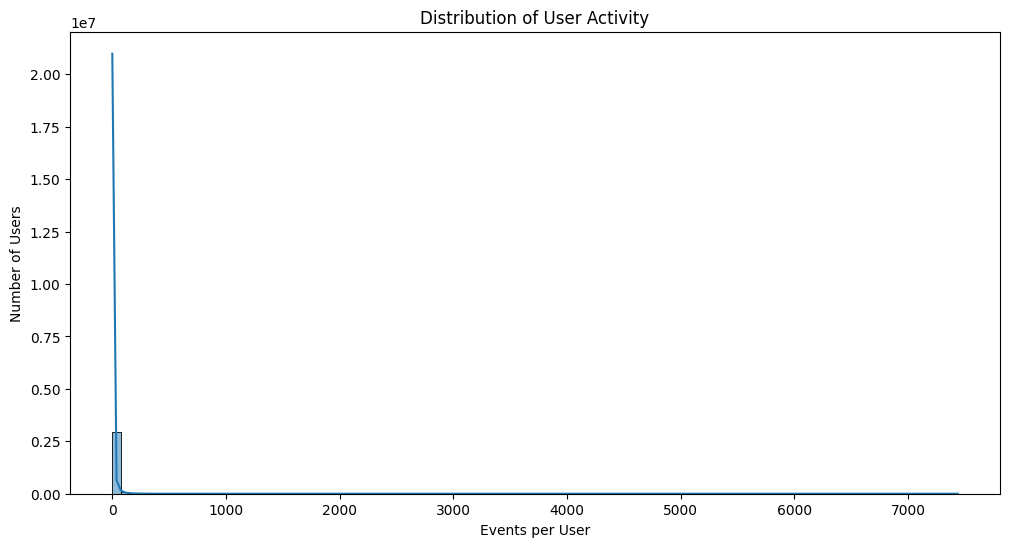

In [23]:
plt.figure(figsize=(12, 6))

sns.histplot(
    user_activity["EventCount"],
    bins=100,
    kde=True
)

plt.title("Distribution of User Activity")
plt.xlabel("Events per User")
plt.ylabel("Number of Users")

plt.show()

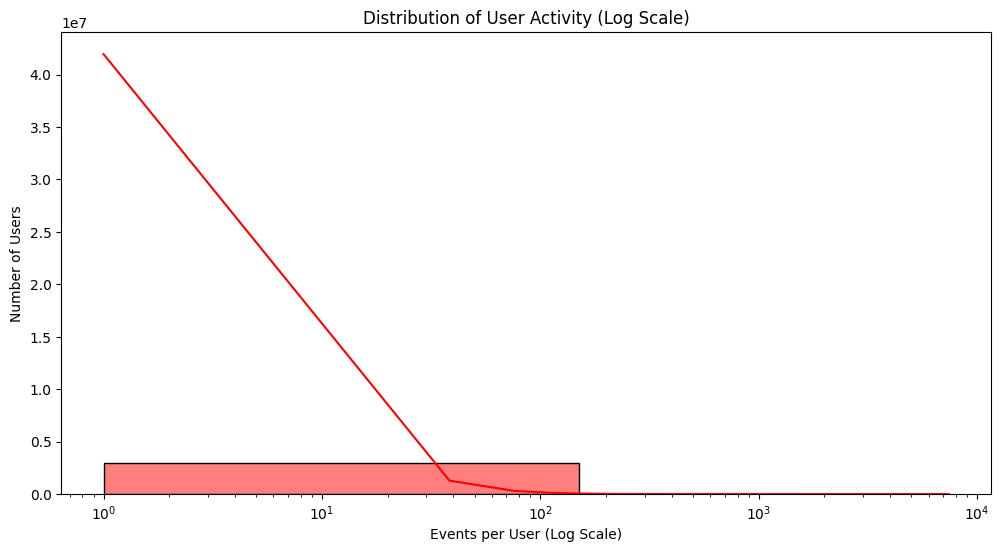

In [24]:
plt.figure(figsize=(12, 6))

sns.histplot(
    user_activity["EventCount"],
    bins=50, # fewer bins to show the skewed distribution more clearly
    color="red",
    kde=True
)

# Data is Highly Skewed - Log Scale Helps Visualize the Distribution Better
# more readable x-axis for skewed data 
plt.xscale("log")

plt.title("Distribution of User Activity (Log Scale)")
plt.xlabel("Events per User (Log Scale)")
plt.ylabel("Number of Users")

plt.show()

**User Activity Level**

Users are overwhelmingly `lightly active`. Approximately 99.995% of users generated fewer than 1,000 events, while only 292 users (0.005%) exceeded 1,000 events.

**Engagement Distribution**

Engagement is highly `unevenly distributed`. The vast majority of users generate relatively few interactions, while a very small group of users contributes substantially more activity.

**Contribution of Highly Active Users**

A relatively small group of highly active users likely generates a disproportionate share of total events. This pattern is common in e-commerce platforms and suggests the presence of a small number of power users.

**Risks of Low Engagement**

Low engagement may lead to:

- Lower conversion opportunities.
- Reduced customer retention.
- Lower customer lifetime value.
- Increased dependence on acquiring new users.

**Opportunities to Increase Engagement**

Possible initiatives include:

- Improve `product recommendations`.
- Personalize the shopping experience.
- Send targeted `email` or `push notification` campaigns.
- Encourage repeat visits through promotions and loyalty programs.
- Improve product discovery and search functionality.

---

## **Retention and Cohort Analysis**

Do users come back after their first visit?

**User User First Activity Date**

In [25]:
first_activity = (
    df.groupby("user_id")["event_time"]
    .min()
    .reset_index()
)

In [26]:

first_activity.columns = [
    "user_id",
    "FirstActivityDate"
]

first_activity

,user_id,FirstActivityDate
0,33869381,2019-10-23 20:04:08+00:00
1,64078358,2019-10-13 00:13:46+00:00
2,183503497,2019-10-02 21:43:00+00:00
3,184265397,2019-10-04 17:44:37+00:00
4,195082191,2019-10-10 03:35:36+00:00
...,...,...
3022285,566280663,2019-10-31 23:58:19+00:00
3022286,566280676,2019-10-31 23:58:39+00:00
3022287,566280697,2019-10-31 23:58:56+00:00
3022288,566280780,2019-10-31 23:59:02+00:00


**Attach First Activity to Every Event**

In [27]:
df = df.merge(
    first_activity,
    on="user_id",
    how="left"
)

In [28]:
df[["event_time", "FirstActivityDate"]]

,event_time,FirstActivityDate
0,2019-10-01 00:00:00+00:00,2019-10-01 00:00:00+00:00
1,2019-10-01 00:00:00+00:00,2019-10-01 00:00:00+00:00
2,2019-10-01 00:00:01+00:00,2019-10-01 00:00:01+00:00
3,2019-10-01 00:00:01+00:00,2019-10-01 00:00:01+00:00
4,2019-10-01 00:00:04+00:00,2019-10-01 00:00:04+00:00
...,...,...
42448759,2019-10-31 23:59:58+00:00,2019-10-04 11:32:55+00:00
42448760,2019-10-31 23:59:58+00:00,2019-10-01 04:44:45+00:00
42448761,2019-10-31 23:59:58+00:00,2019-10-31 23:57:24+00:00
42448762,2019-10-31 23:59:59+00:00,2019-10-29 02:08:54+00:00


**Cohort Month**

In [29]:
df["CohortMonth"] = (
    df["FirstActivityDate"]
    .dt.to_period("M")
)

C:\Users\kharc\AppData\Local\Temp\ipykernel_20048\2756709747.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


**Activity Month**

In [30]:
last_activity = (
    df.groupby("user_id")["event_time"]
    .max().dt.to_period("M")
    .reset_index()
)

last_activity.columns = [
    "user_id",
    "ActivityMonth"
]

df = df.merge(
    last_activity,
    on="user_id",
    how="left"
)

C:\Users\kharc\AppData\Local\Temp\ipykernel_20048\3417263520.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .max().dt.to_period("M")


In [31]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,FirstActivityDate,CohortMonth,ActivityMonth
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,2019-10-01 00:00:00+00:00,2019-10,2019-10
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,2019-10-01 00:00:00+00:00,2019-10,2019-10
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,2019-10-01 00:00:01+00:00,2019-10,2019-10
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,2019-10-01 00:00:01+00:00,2019-10,2019-10
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01 00:00:04+00:00,2019-10,2019-10
...,...,...,...,...,...,...,...,...,...,...,...,...
42448759,2019-10-31 23:59:58+00:00,view,2300275,2053013560530830019,electronics.camera.video,gopro,527.40,537931532,22c57267-da98-4f28-9a9c-18bb5b385193,2019-10-04 11:32:55+00:00,2019-10,2019-10
42448760,2019-10-31 23:59:58+00:00,view,10800172,2053013554994348409,NaN,redmond,61.75,527322328,5054190a-46cb-4211-a8f1-16fc1a060ed8,2019-10-01 04:44:45+00:00,2019-10,2019-10
42448761,2019-10-31 23:59:58+00:00,view,5701038,2053013553970938175,auto.accessories.player,kenwood,128.70,566280422,05b6c62b-992f-4e8e-91f7-961bcb4719cd,2019-10-31 23:57:24+00:00,2019-10,2019-10
42448762,2019-10-31 23:59:59+00:00,view,21407424,2053013561579406073,electronics.clocks,tissot,689.85,513118352,4c14bf2a-2820-4504-929d-046356a5a204,2019-10-29 02:08:54+00:00,2019-10,2019-10


**Cohort Index**

In [32]:
df["CohortIndex"] = (
    (df["ActivityMonth"].dt.year -
     df["CohortMonth"].dt.year) * 12
    +
    (df["ActivityMonth"].dt.month -
     df["CohortMonth"].dt.month)
    + 1
)

In [33]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,FirstActivityDate,CohortMonth,ActivityMonth,CohortIndex
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,2019-10-01 00:00:00+00:00,2019-10,2019-10,1
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,2019-10-01 00:00:00+00:00,2019-10,2019-10,1
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,2019-10-01 00:00:01+00:00,2019-10,2019-10,1
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,2019-10-01 00:00:01+00:00,2019-10,2019-10,1
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01 00:00:04+00:00,2019-10,2019-10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42448759,2019-10-31 23:59:58+00:00,view,2300275,2053013560530830019,electronics.camera.video,gopro,527.40,537931532,22c57267-da98-4f28-9a9c-18bb5b385193,2019-10-04 11:32:55+00:00,2019-10,2019-10,1
42448760,2019-10-31 23:59:58+00:00,view,10800172,2053013554994348409,NaN,redmond,61.75,527322328,5054190a-46cb-4211-a8f1-16fc1a060ed8,2019-10-01 04:44:45+00:00,2019-10,2019-10,1
42448761,2019-10-31 23:59:58+00:00,view,5701038,2053013553970938175,auto.accessories.player,kenwood,128.70,566280422,05b6c62b-992f-4e8e-91f7-961bcb4719cd,2019-10-31 23:57:24+00:00,2019-10,2019-10,1
42448762,2019-10-31 23:59:59+00:00,view,21407424,2053013561579406073,electronics.clocks,tissot,689.85,513118352,4c14bf2a-2820-4504-929d-046356a5a204,2019-10-29 02:08:54+00:00,2019-10,2019-10,1


In [34]:
df["CohortIndex"].max()

np.int64(1)

**Inspect Active Users**

In [35]:
cohort_data = (
    df.groupby(
        ["CohortMonth", "CohortIndex"]
    )["user_id"]
    .nunique()
    .reset_index()
)

In [36]:
cohort_data

,CohortMonth,CohortIndex,user_id
0,2019-10,1,3022290


**Cohort Table**

In [37]:
cohort_table = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="user_id"
)

In [38]:
cohort_table.head()

CohortIndex,1
CohortMonth,
2019-10,3022290


**Calculate Retention**

In [39]:
cohort_sizes = cohort_table.iloc[:, 0]
retention = cohort_table.divide(
    cohort_sizes,
    axis=0
)

retention.head()

CohortIndex,1
CohortMonth,
2019-10,1.0


**Retention Heatmap**

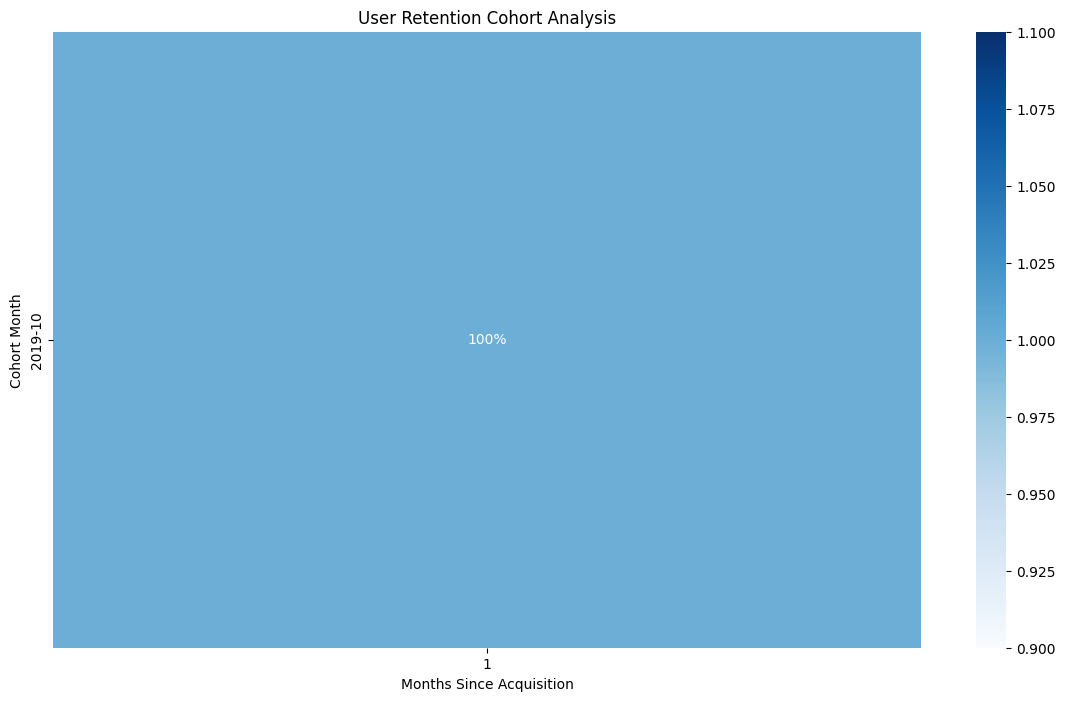

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("User Retention Cohort Analysis")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since Acquisition")

plt.show()

#### **Cohort Analysis Limitation**

The dataset contains activity from a single month (October 2019).

As a result:

- CohortIndex `never exceeds 1`.
- Retention cannot be measured across months.
- All users belong to the `same acquisition cohort`.

A meaningful `retention analysis` requires `multiple months` of user activity data.

Although long-term retention `cannot` be measured because the dataset contains `only one month` of activity, `funnel analysis` shows that `approximately 1.75%` of product `view events` ultimately resulted in a `purchase event`. This indicates that only a `small fraction` of browsing activity is converted into `transactions`, highlighting a significant opportunity to `optimize the customer journey` and improve conversion performance.

---

## **Churn and Engagement Risk Analysis**

**User-Level Metrics**

In [41]:
user_profile = (
    df.groupby("user_id")
    .agg(
        TotalEvents=("event_type", "count"),
        UniqueSessions=("user_session", "nunique"),
        UniqueProducts=("product_id", "nunique")
    )
    .reset_index()
)

In [42]:
user_profile.head()

,user_id,TotalEvents,UniqueSessions,UniqueProducts
0,33869381,1,1,1
1,64078358,1,1,1
2,183503497,1,1,1
3,184265397,6,2,3
4,195082191,1,1,1


**Engagement Score**

In [43]:
user_profile["EngagementScore"] = (
    user_profile["TotalEvents"] * 0.5
    +
    user_profile["UniqueSessions"] * 0.3
    +
    user_profile["UniqueProducts"] * 0.2
)

In [44]:
user_profile

,user_id,TotalEvents,UniqueSessions,UniqueProducts,EngagementScore
0,33869381,1,1,1,1.0
1,64078358,1,1,1,1.0
2,183503497,1,1,1,1.0
3,184265397,6,2,3,4.2
4,195082191,1,1,1,1.0
...,...,...,...,...,...
3022285,566280663,2,1,1,1.5
3022286,566280676,1,1,1,1.0
3022287,566280697,1,1,1,1.0
3022288,566280780,1,1,1,1.0


**Engagement Segments**

In [45]:
user_profile["EngagementSegment"] = pd.qcut(
    user_profile["EngagementScore"],
    q=4,
    labels=[
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement",
        "Power Users"
    ]
)

In [46]:
user_profile

,user_id,TotalEvents,UniqueSessions,UniqueProducts,EngagementScore,EngagementSegment
0,33869381,1,1,1,1.0,Low Engagement
1,64078358,1,1,1,1.0,Low Engagement
2,183503497,1,1,1,1.0,Low Engagement
3,184265397,6,2,3,4.2,High Engagement
4,195082191,1,1,1,1.0,Low Engagement
...,...,...,...,...,...,...
3022285,566280663,2,1,1,1.5,Low Engagement
3022286,566280676,1,1,1,1.0,Low Engagement
3022287,566280697,1,1,1,1.0,Low Engagement
3022288,566280780,1,1,1,1.0,Low Engagement


**Segment Distribution**

In [47]:
segment_distribution = (
    user_profile["EngagementSegment"]
    .value_counts()
    .reset_index()
)

In [48]:
segment_distribution

,EngagementSegment,count
0,Low Engagement,811353
1,High Engagement,757491
2,Power Users,752918
3,Moderate Engagement,700528


**Segment KPI Table**

In [49]:
segment_summary = (
    user_profile.groupby("EngagementSegment")
    .agg(
        Users=("user_id", "count"),
        AvgEvents=("TotalEvents", "mean"),
        AvgSessions=("UniqueSessions", "mean"),
        AvgProducts=("UniqueProducts", "mean")
    )
    .round(2)
)

In [50]:
segment_summary

,Users,AvgEvents,AvgSessions,AvgProducts
EngagementSegment,,,,
Low Engagement,811353,1.15,1.00,1.00
Moderate Engagement,700528,2.97,1.45,2.08
High Engagement,757491,7.97,2.44,5.09
Power Users,752918,44.36,7.41,22.83


**Visualize Segments**

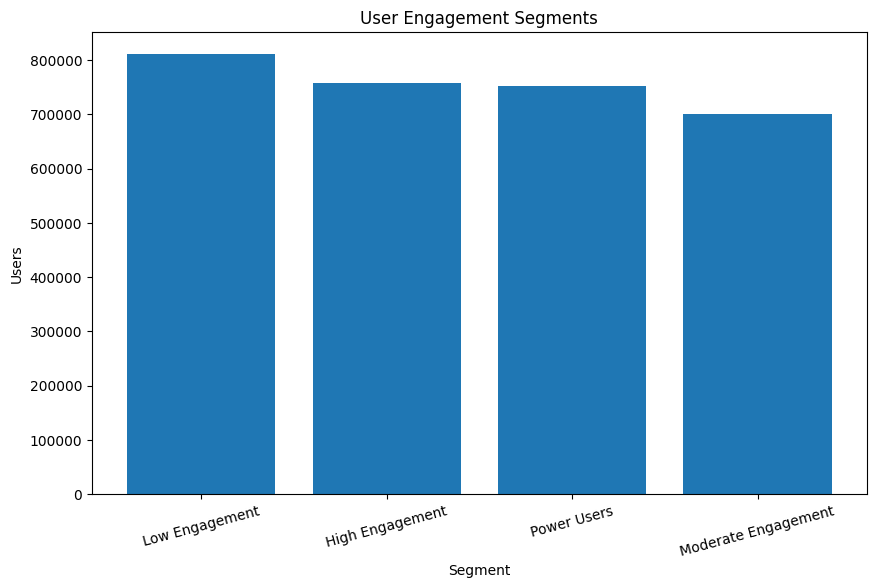

In [51]:
plt.figure(figsize=(10,6))

plt.bar(
    segment_distribution["EngagementSegment"],
    segment_distribution["count"],
    
)

plt.title("User Engagement Segments")

plt.xlabel("Segment")

plt.ylabel("Users")

plt.xticks(rotation=15)

plt.show()

**Executive Interpretation**

**Low Engagement Population**

Approximately `26.85%` of users belong to the `Low Engagement` segment.

**Importance of Low-Engagement Users**

They represent a large opportunity for improving engagement, conversions, and retention.

**Business Risk**

Low-engagement users are more likely to leave the platform without returning or making a purchase.

**Recommended Product Response**

Identify barriers to engagement and improve the user experience for this segment.

**Actions to Increase Engagement**

- Improve `product recommendations`.
- Personalize the shopping experience.
- Offer promotions and loyalty incentives.
- Use targeted `email` and `push notification` campaigns.

---

## **Product KPI Dashboard**

**Date Columns**

In [54]:
# Extract calendar dimensions for KPI calculations.

df["Date"] = df["event_time"].dt.date
df["Week"] = df["event_time"].dt.to_period("W")
df["Month"] = df["event_time"].dt.to_period("M")

C:\Users\kharc\AppData\Local\Temp\ipykernel_20048\774507140.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["Week"] = df["event_time"].dt.to_period("W")
C:\Users\kharc\AppData\Local\Temp\ipykernel_20048\774507140.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["Month"] = df["event_time"].dt.to_period("M")


In [57]:
df[["Date", "Week", "Month"]]

,Date,Week,Month
0,2019-10-01,2019-09-30/2019-10-06,2019-10
1,2019-10-01,2019-09-30/2019-10-06,2019-10
2,2019-10-01,2019-09-30/2019-10-06,2019-10
3,2019-10-01,2019-09-30/2019-10-06,2019-10
4,2019-10-01,2019-09-30/2019-10-06,2019-10
...,...,...,...
42448759,2019-10-31,2019-10-28/2019-11-03,2019-10
42448760,2019-10-31,2019-10-28/2019-11-03,2019-10
42448761,2019-10-31,2019-10-28/2019-11-03,2019-10
42448762,2019-10-31,2019-10-28/2019-11-03,2019-10


**Daily/Weelky/Monthly (AU-Active Users-)**

In [58]:
# DAU
daily_active_users = (
    df.groupby("Date")["user_id"]
    .nunique()
    .reset_index(name="DAU")
)
# WAU
weekly_active_users = (
    df.groupby("Week")["user_id"]
    .nunique()
    .reset_index(name="WAU")
)
# MAU
monthly_active_users = (
    df.groupby("Month")["user_id"]
    .nunique()
    .reset_index(name="MAU")
)

In [59]:
daily_active_users

,Date,DAU
0,2019-10-01,190188
1,2019-10-02,184965
2,2019-10-03,170668
3,2019-10-04,209410
4,2019-10-05,194958
5,2019-10-06,193210
6,2019-10-07,186951
7,2019-10-08,221204
8,2019-10-09,214140
9,2019-10-10,205321


In [60]:
weekly_active_users

,Week,WAU
0,2019-09-30/2019-10-06,851711
1,2019-10-07/2019-10-13,1057754
2,2019-10-14/2019-10-20,1095864
3,2019-10-21/2019-10-27,1089896
4,2019-10-28/2019-11-03,633487


In [61]:
monthly_active_users

,Month,MAU
0,2019-10,3022290


**Obs**

Since this dataset contains only October: Expect `one MAU value`.

**Average DAU**

In [69]:
average_dau = daily_active_users["DAU"].mean()

print(f"Average of daily active users is: {average_dau.round(3)}")

Average of daily active users is: 208829.774


**Calculate Stickiness**

In [73]:
mau = monthly_active_users["MAU"].iloc[0]

stickiness = (
    average_dau / mau
) * 100

print(f"stickiness =  {stickiness.round(2)}")

stickiness =  6.91


**Interpretation**:

On an average day, approximately 7% of monthly active users return to the platform.

In [74]:
product_kpis = pd.DataFrame({
    "KPI": [
        "Average DAU",
        "MAU",
        "Stickiness (%)",
        "Total Users",
        "Total Events",
        "Average Events per User"
    ],

    "Value": [
        round(average_dau, 2),
        mau,
        round(stickiness, 2),
        df["user_id"].nunique(),
        len(df),
        round(
            len(df) /
            df["user_id"].nunique(),
            2
        )
    ]
})

product_kpis

,KPI,Value
0,Average DAU,208829.77
1,MAU,3022290.00
2,Stickiness (%),6.91
3,Total Users,3022290.00
4,Total Events,42448764.00
5,Average Events per User,14.05


**DAU Trend**

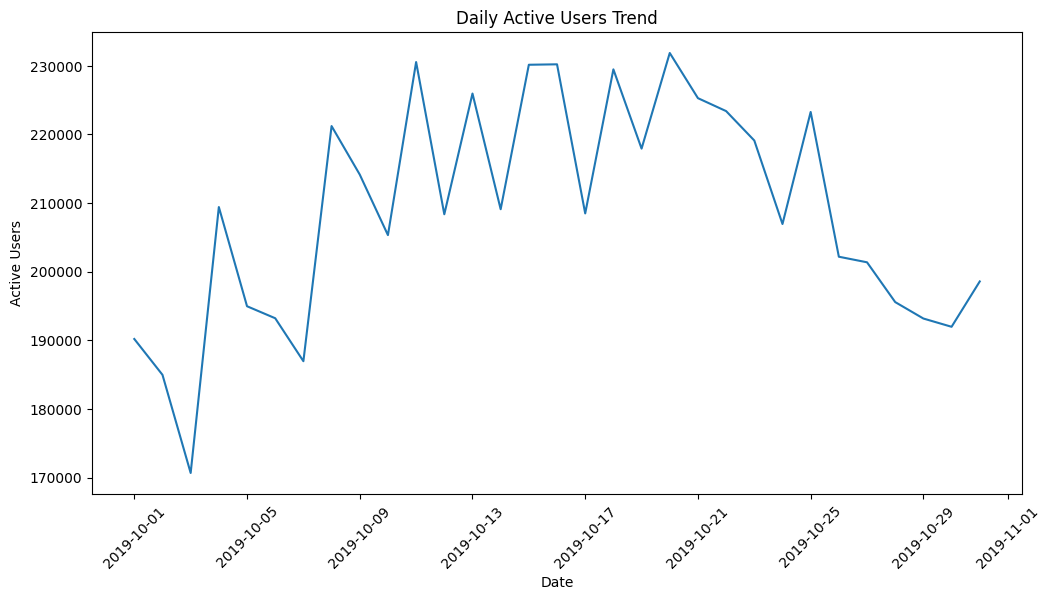

In [75]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_active_users["Date"],
    daily_active_users["DAU"]
)

plt.title("Daily Active Users Trend")

plt.xlabel("Date")

plt.ylabel("Active Users")

plt.xticks(rotation=45)

plt.show()

**DAU**

`DAU` shows how many users visit the platform each day.

**MAU**

`MAU` shows how many users visit the platform during the month.

**Stickiness**

`Stickiness` indicates how often users return.

**Is the Product Habit-Forming?**

The platform has strong daily activity, but the stickiness rate determines whether users return regularly.

**Risks**

- Users may visit once and never return.
- Low retention can hurt future growth.

**Recommendations**

- Improve `product recommendations`.
- Send reminder emails and notifications.
- Offer promotions and loyalty rewards.

---

## **Executive Storytelling**

I analyzed over `42 million` user events from `3 million users`.

I discovered that only `1.75%` of view events converted into purchases,
indicating `significant drop-off` in the customer journey.

`User engagement` was heavily concentrated among a `small group of power users`,
suggesting an opportunity to improve activation and engagement among the broader user base.

Based on these findings, I recommended improvements in product discovery,
personalization, and re-engagement strategies.